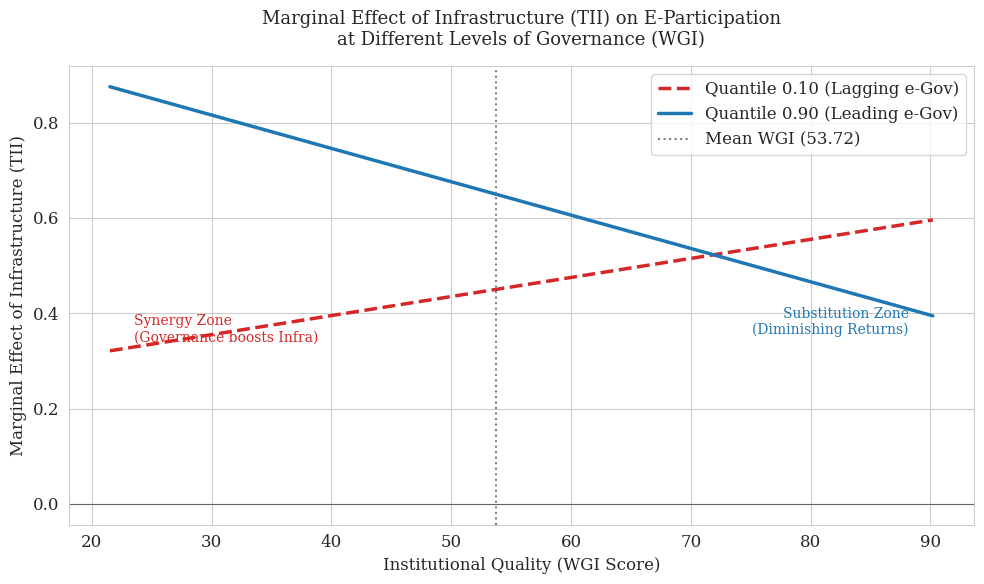

In [1]:
# شکل 2 جدید

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# تنظیمات گرافیکی استاندارد مقاله
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 12

# === تنظیم دقیق داده‌ها ===
wgi_min = 21.52  
wgi_max = 90.20  
wgi_mean = 53.72 

# ایجاد دامنه برای محور X
wgi_levels = np.linspace(wgi_min, wgi_max, 100)

# === جایگذاری اعداد دقیق Table 2 ===
# Q10 (Lagging): اثر مثبت و فزاینده (هم‌افزایی)
beta_tii_q10 = 0.45    # دقت کنید این عدد دقیقا ضریب TII در دهک 0.10 باشد
beta_int_q10 = 0.004   # عدد اصلاح شده طبق خروجی جدول

# Q90 (Leading): اثر مثبت اما کاهنده (اشباع/جایگزینی)
beta_tii_q90 = 0.65    # دقت کنید این عدد دقیقا ضریب TII در دهک 0.90 باشد
beta_int_q90 = -0.007  # عدد اصلاح شده طبق خروجی جدول

# محاسبه اثر حاشیه‌ای (Mean-Centered Approach)
me_q10 = beta_tii_q10 + beta_int_q10 * (wgi_levels - wgi_mean)
me_q90 = beta_tii_q90 + beta_int_q90 * (wgi_levels - wgi_mean)

# رسم نمودار
plt.figure(figsize=(10, 6))

plt.plot(wgi_levels, me_q10, label='Quantile 0.10 (Lagging e-Gov)', color='#d62728', linewidth=2.5, linestyle='--')
plt.plot(wgi_levels, me_q90, label='Quantile 0.90 (Leading e-Gov)', color='#1f77b4', linewidth=2.5)

plt.axhline(0, color='black', linewidth=0.8, alpha=0.5)
plt.axvline(wgi_mean, color='gray', linestyle=':', label=f'Mean WGI ({wgi_mean})')

# Annotations
plt.text(wgi_min + 2, me_q10[5], 'Synergy Zone\n(Governance boosts Infra)', fontsize=10, color='#d62728', verticalalignment='bottom')
plt.text(wgi_max - 2, me_q90[-5], 'Substitution Zone\n(Diminishing Returns)', fontsize=10, color='#1f77b4', horizontalalignment='right', verticalalignment='top')

plt.title('Marginal Effect of Infrastructure (TII) on E-Participation\nat Different Levels of Governance (WGI)', fontsize=13, pad=15)
plt.xlabel('Institutional Quality (WGI Score)', fontsize=12)
plt.ylabel('Marginal Effect of Infrastructure (TII)', fontsize=12)
plt.legend(loc='best', frameon=True)

plt.tight_layout()

# ذخیره
plt.savefig('Figure3_Interaction_Effect.png', dpi=300, bbox_inches='tight')
plt.savefig('Figure3_Interaction_Effect.pdf', format='pdf', bbox_inches='tight')

plt.show()
